In [1]:
import numpy as np

import matplotlib.pyplot as plt

from ase.visualize import view
from ase.build import graphene
from ase.calculators.tersoff import Tersoff, TersoffParameters

In [2]:
atoms = graphene(a=2.459829)
view(atoms, viewer='x3d')

In [3]:
# Define Tersoff parameters for Si
c_params = {
    ("C", "C", "C"): TersoffParameters(
        A=1393.6,        # eV
        B=346.74,        # eV
        lambda1=3.4879,  # Å^-1
        lambda2=2.2119,  # Å^-1
        lambda3=0.0,     # Å^-1
        beta=1.5724e-7,
        gamma=1.0,
        m=3.0,
        n=0.72751,
        c=38049.0,
        d=4.3484,
        h=-0.57058,      # Keep 'h' (corresponds to cos θ₀)
        R=1.8,           # Cutoff R (Carbon drops off earlier than Silicon)
        D=0.2,           # Cutoff range D
    )
}

# Set up calculator
calc = Tersoff(c_params)
atoms.calc = calc

atoms.calc = calc
atoms.cell[2][2] = 100

### optimize structure

In [4]:
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter, ExpCellFilter

filter = ExpCellFilter(atoms, mask = [1,1,0,0,0,0])
opt = BFGS(filter)
opt.run(fmax=1e-5)

atoms.calc = calc
view(atoms, viewer='x3d')

      Step     Time          Energy          fmax
BFGS:    0 12:15:35      -14.690817        3.666116
BFGS:    1 12:15:35      -14.729007        2.635361
BFGS:    2 12:15:35      -14.790546        0.243874
BFGS:    3 12:15:35      -14.791035        0.018907
BFGS:    4 12:15:35      -14.791038        0.000121
BFGS:    5 12:15:36      -14.791038        0.000000


/tmp/ipykernel_26397/3389028746.py:4: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  filter = ExpCellFilter(atoms, mask = [1,1,0,0,0,0])


In [5]:
atoms = atoms.repeat((10, 10,1))
atoms.calc = calc

i0=0
i1=1
p0 = atoms.positions[0]
p1=atoms.positions[1]

nndistance = np.linalg.norm(p1 - p0)
print("neirest neighbor distance:", nndistance)

neirest neighbor distance: 1.4605105458282568


## Change positions of i0 and i1 atoms and measure potential energy

- Due to the environment, I expect the energy to change in a non trivial way.
- There are 4 independent variables to change.
- There are some simmetries.
- I choose center of mass, oriantation and relative distance as coordinates

In [6]:
CM = (p1 + p0)/2.
ANGLE=0
D=nndistance

print("CM:", CM)
print("ANGLE:", ANGLE)
print("D", D)

CM: [6.32419618e-01 3.65127636e-01 2.47216878e-18]
ANGLE: 0
D 1.4605105458282568


In [7]:
atoms.get_potential_energy()
atoms.get_forces()

array([[ 8.54871729e-15, -1.43982487e-12,  1.28026386e-18],
       [ 9.88098492e-15,  1.30273570e-12, -1.28026386e-18],
       [-3.13638004e-14, -1.50079948e-12,  1.28026386e-18],
       [-1.15463195e-14,  1.31992079e-12, -1.28026386e-18],
       [-1.15518706e-13, -1.33293376e-12,  1.28026386e-18],
       [-4.77395901e-15,  1.22792858e-12, -1.28026386e-18],
       [-3.99680289e-15, -1.41431311e-12,  1.28026386e-18],
       [ 4.19664303e-14,  1.28102061e-12, -1.28026386e-18],
       [-1.06081810e-13, -1.34880995e-12,  1.28026386e-18],
       [ 6.17284002e-14,  1.24769055e-12, -1.28026386e-18],
       [ 3.83026943e-15, -1.43129952e-12,  1.28026386e-18],
       [-3.31956684e-14,  1.28341782e-12, -1.28026386e-18],
       [-1.27897692e-13, -1.35824685e-12,  1.28026386e-18],
       [-1.62092562e-14,  1.26065824e-12, -1.28026386e-18],
       [-8.49320614e-15, -1.46549439e-12,  1.28026386e-18],
       [-3.33066907e-16,  1.60014108e-12, -1.28026386e-18],
       [-1.66533454e-16, -1.31517019e-12

In [8]:
atoms.get_potential_energy()

np.float64(-1479.103826448269)

In [9]:
from tqdm import tqdm

# ---- scan parameters ----
d_values = np.linspace(D*0.9, D*1.5, 100)
angle_values = np.linspace(0, np.pi/2, 100)

# storage
distances = []
angles = []
energies = []
forces0 = []
forces1 = []

# reference geometry
base_positions = atoms.get_positions().copy()

# bond direction
v0 = base_positions[1] - base_positions[0]
v0 = v0 / np.linalg.norm(v0)

for d in tqdm(d_values):

    for angle in angle_values:

        pos = base_positions.copy()

        # rotation matrix (xy plane)
        rot = np.array([
            [np.cos(angle), -np.sin(angle), 0],
            [np.sin(angle),  np.cos(angle), 0],
            [0,0,1]
        ])

        v_rot = rot @ v0

        # keep center fixed
        pos[0] = CM - 0.5*d*v_rot
        pos[1] = CM + 0.5*d*v_rot

        atoms.set_positions(pos)

        # evaluation
        E = atoms.get_potential_energy()
        F = atoms.get_forces()

        distances.append(d)
        angles.append(angle)
        energies.append(E)
        forces0.append(F[0].copy())
        forces1.append(F[1].copy())

print("Computed points:", len(energies))


100%|██████████| 100/100 [14:43<00:00,  8.83s/it]

Computed points: 10000


In [10]:
from numpy import meshgrid

gridpoints = meshgrid(angle_values, d_values)

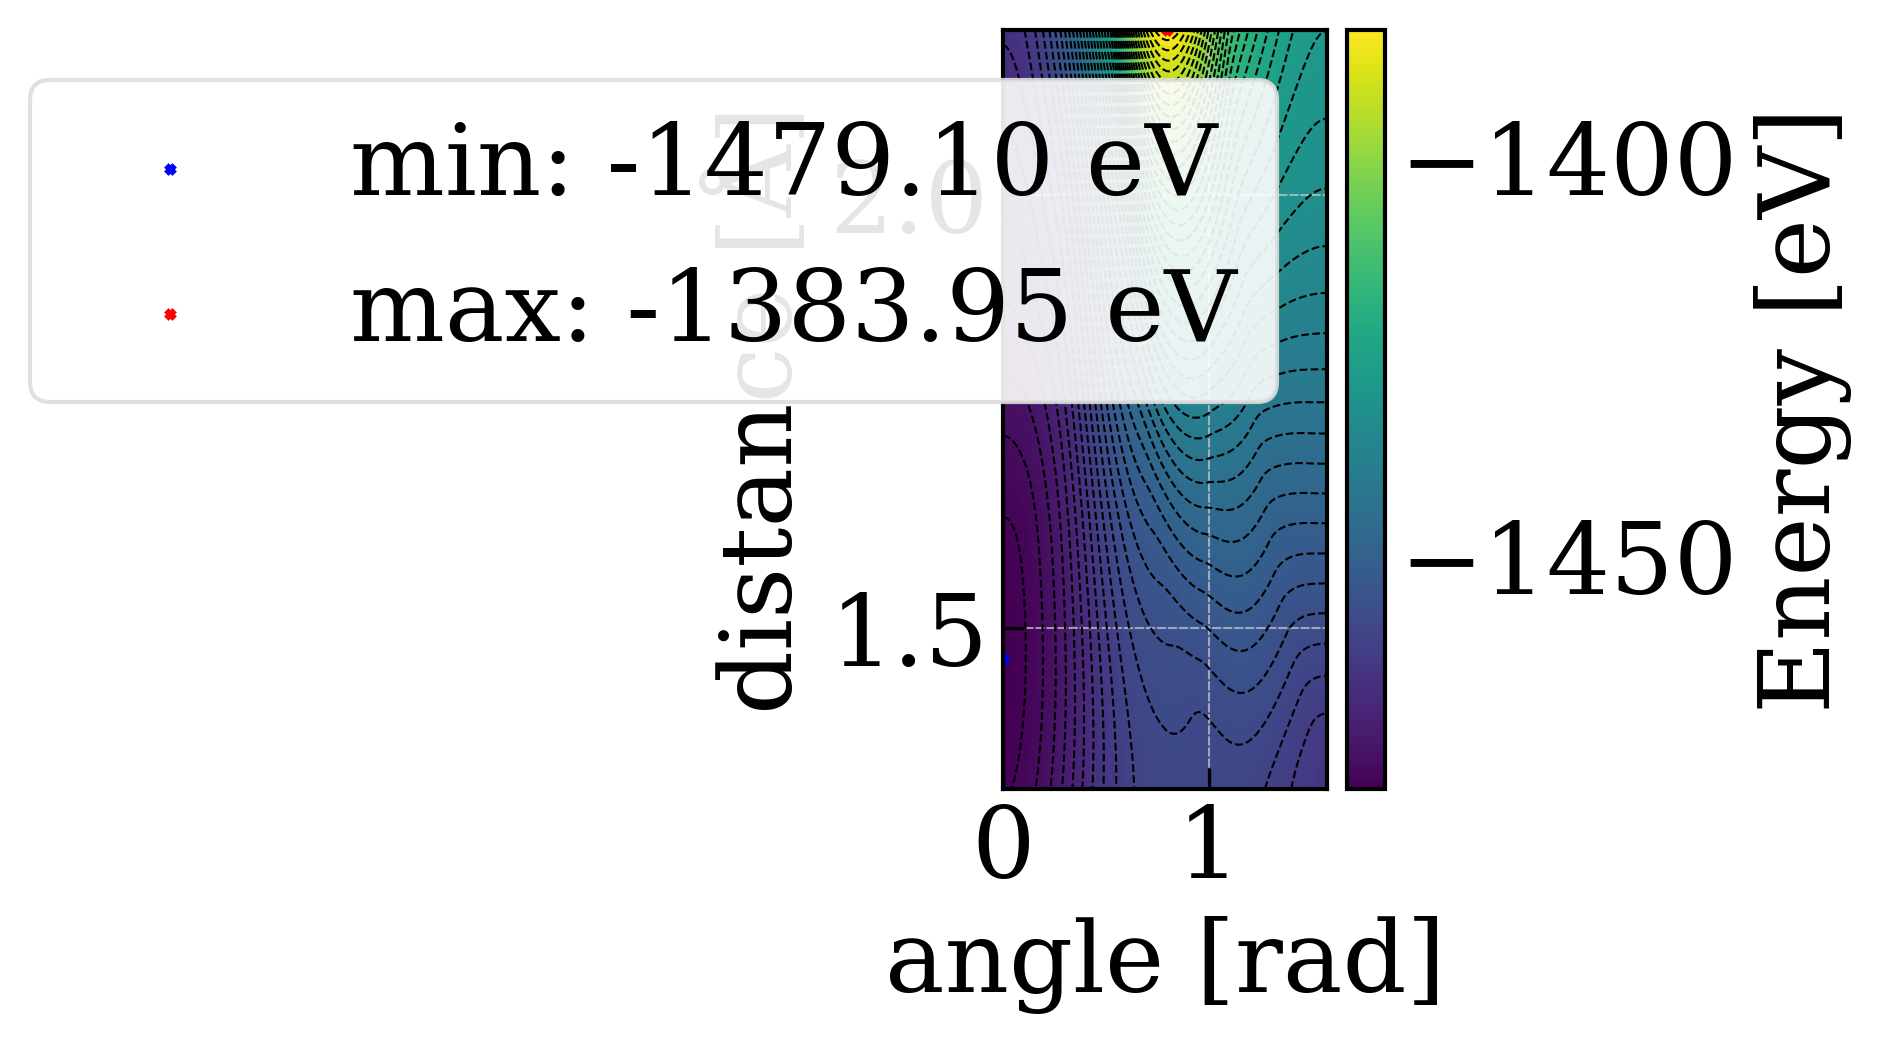

In [11]:
E_surface = np.array(energies).reshape(len(d_values), len(angle_values))
plt.imshow(E_surface, origin="lower",
           extent=[angle_values[0], angle_values[-1],
                   d_values[0], d_values[-1]],
           aspect="auto")
plt.colorbar(label="Energy [eV]")
plt.contour(angle_values, d_values, E_surface, colors="k", levels=50, linewidths=0.5)

mine_idx = np.argmin(E_surface)
mine = E_surface.flatten()[mine_idx]
maxe_idx = np.argmax(E_surface)
maxe = E_surface.flatten()[maxe_idx]
gridmin = gridpoints[0].flatten()[mine_idx], gridpoints[1].flatten()[mine_idx]
gridmax = gridpoints[0].flatten()[maxe_idx], gridpoints[1].flatten()[maxe_idx]
plt.scatter(gridmin[0], gridmin[1], marker = "x", color="blue", label=f"min: {mine:.2f} eV")
plt.scatter(gridmax[0], gridmax[1], marker = "x", color="red", label=f"max: {maxe:.2f} eV")

plt.xlabel("angle [rad]")
plt.ylabel("distance [Å]")
plt.legend()

plt.savefig("pe_grid.svg")
plt.show()

In [12]:
forces1 = np.array(forces1).reshape(len(d_values), len(angle_values), 3)
forces0 = np.array(forces0).reshape(len(d_values), len(angle_values), 3)

f0mod = np.linalg.norm(forces0, axis = -1)
f1mod = np.linalg.norm(forces1, axis = -1)


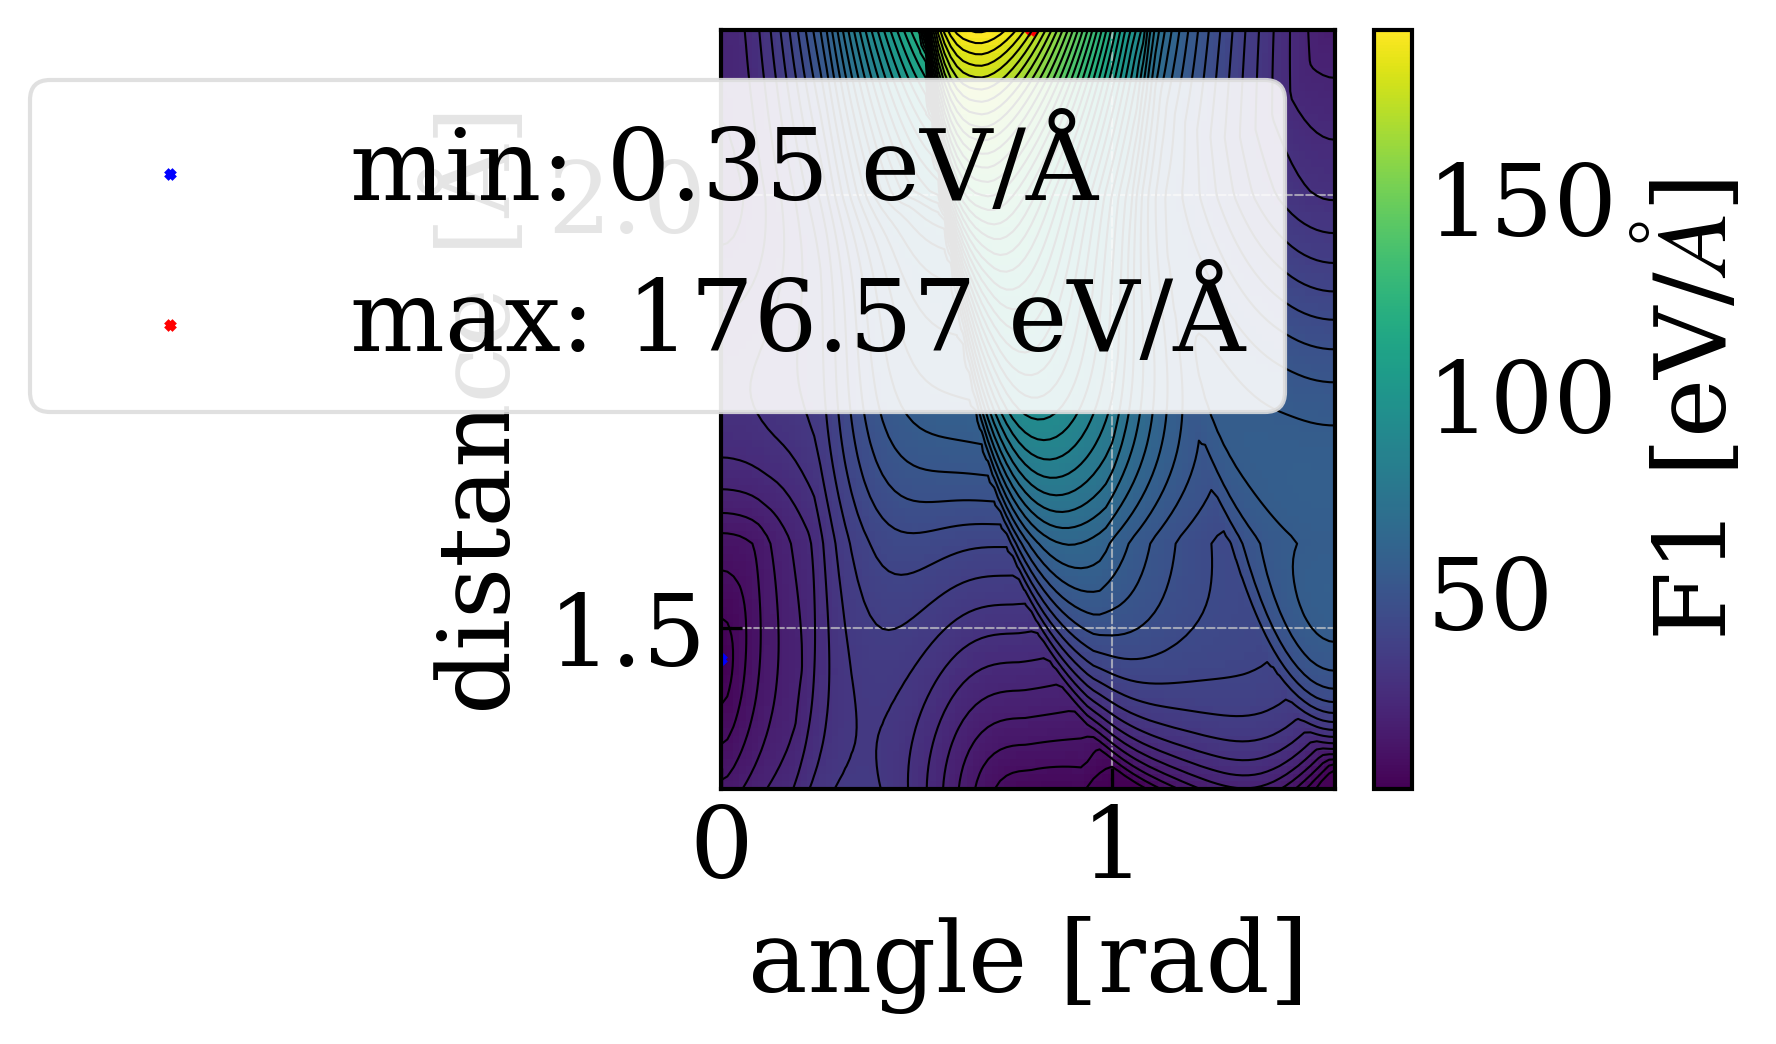

In [13]:
plt.imshow(f1mod[:,:], origin="lower",
           extent=[angle_values[0], angle_values[-1],
                   d_values[0], d_values[-1]],
           aspect="auto")

plt.colorbar(label=r"F1 [eV/$\AA$]")

plt.contour(angle_values, d_values, f1mod, colors="k", levels=50, linewidths=0.5)

gridmin = gridpoints[0].flatten()[mine_idx], gridpoints[1].flatten()[mine_idx]
gridmax = gridpoints[0].flatten()[maxe_idx], gridpoints[1].flatten()[maxe_idx]
plt.scatter(gridmin[0], gridmin[1], marker = "x", color="blue", label=f"min: {f1mod.flatten()[mine_idx]:.2f} eV/Å")
plt.scatter(gridmax[0], gridmax[1], marker = "x", color="red", label=f"max: {f1mod.flatten()[maxe_idx]:.2f} eV/Å")
plt.legend()    

plt.xlabel("angle [rad]")
plt.ylabel("distance [Å]")
plt.savefig("f1_grid.svg")
plt.show()

In [14]:
ND  = 500
DS = np.linspace(1.2, 3, num=ND)
Dforces0=[]
Dforces1=[]
Denergies=[]

for d in tqdm(DS):
    pos = base_positions.copy()

    # keep center fixed
    pos[0] = CM - 0.5*d*v0
    pos[1] = CM + 0.5*d*v0

    atoms.set_positions(pos)

    # evaluation
    E = atoms.get_potential_energy()
    F = atoms.get_forces()

    Denergies.append(E)
    Dforces0.append(F[0].copy())
    Dforces1.append(F[1].copy())

Dforces0=np.array(Dforces0).reshape((ND, 3))
Dforces1=np.array(Dforces1).reshape((ND, 3))
Denergies = np.array(Denergies)

100%|██████████| 500/500 [00:44<00:00, 11.34it/s]


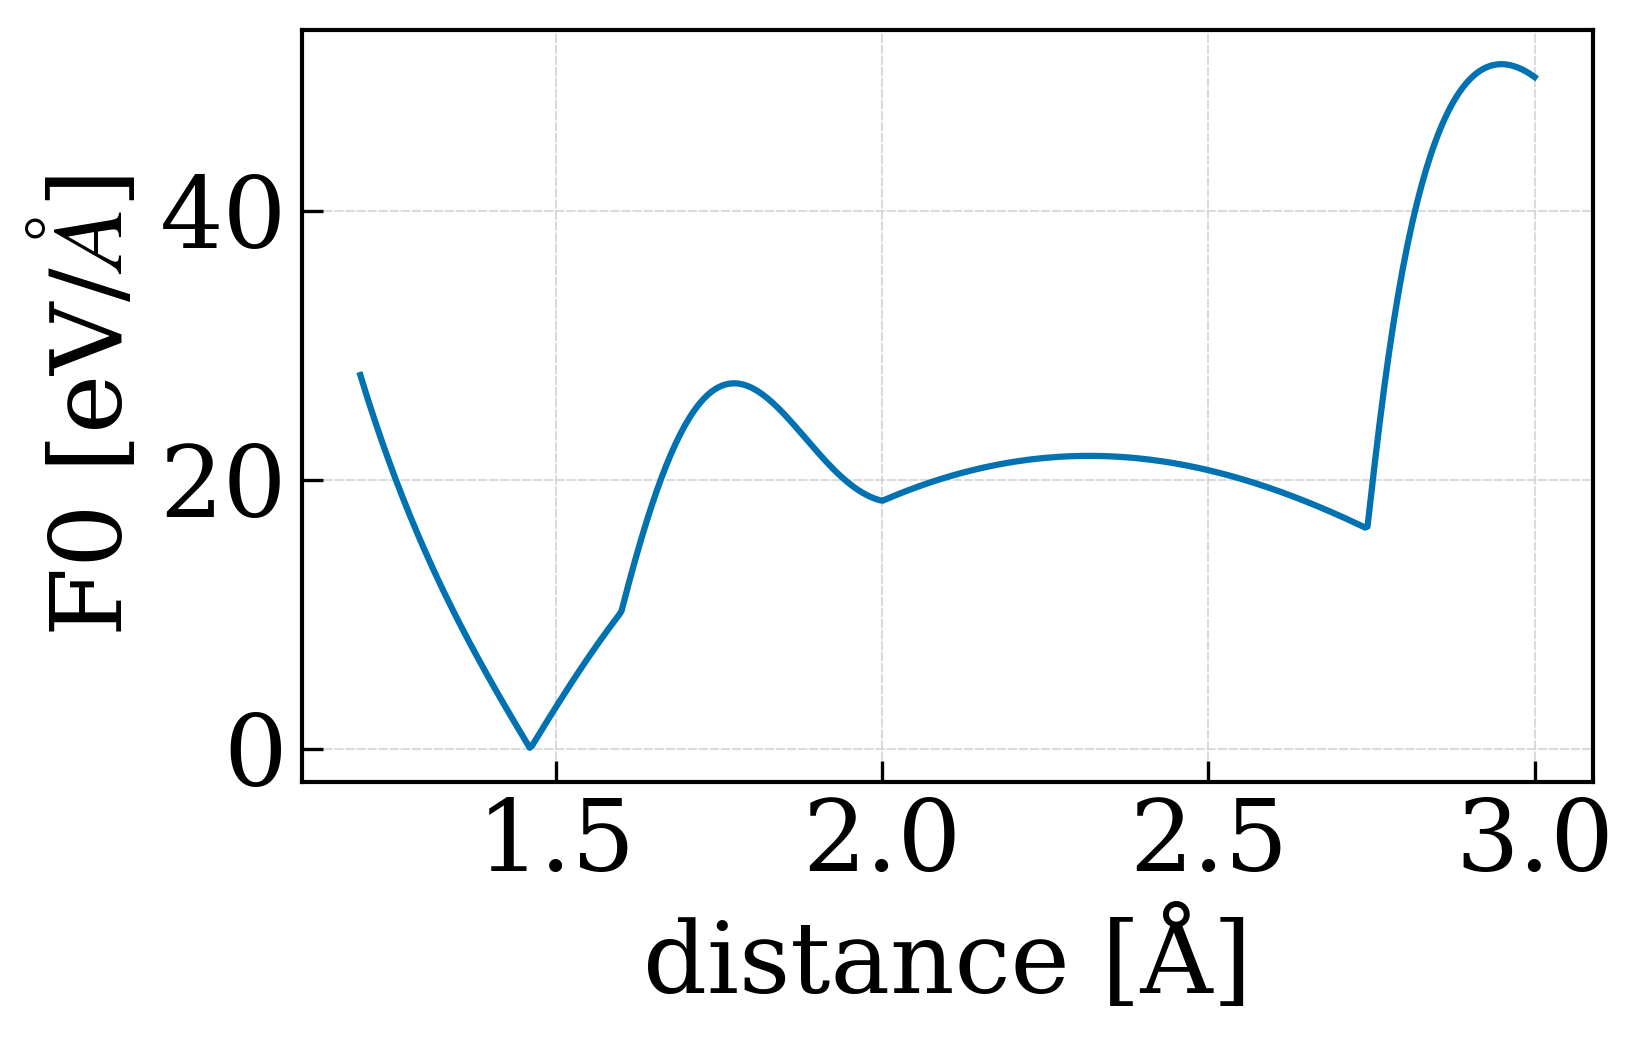

In [15]:
plt.plot(DS, np.linalg.norm(Dforces0, axis=-1))
plt.xlabel("distance [Å]")
plt.ylabel(r"F0 [eV/$\AA$]")
plt.savefig("f0_d.svg")
plt.show()

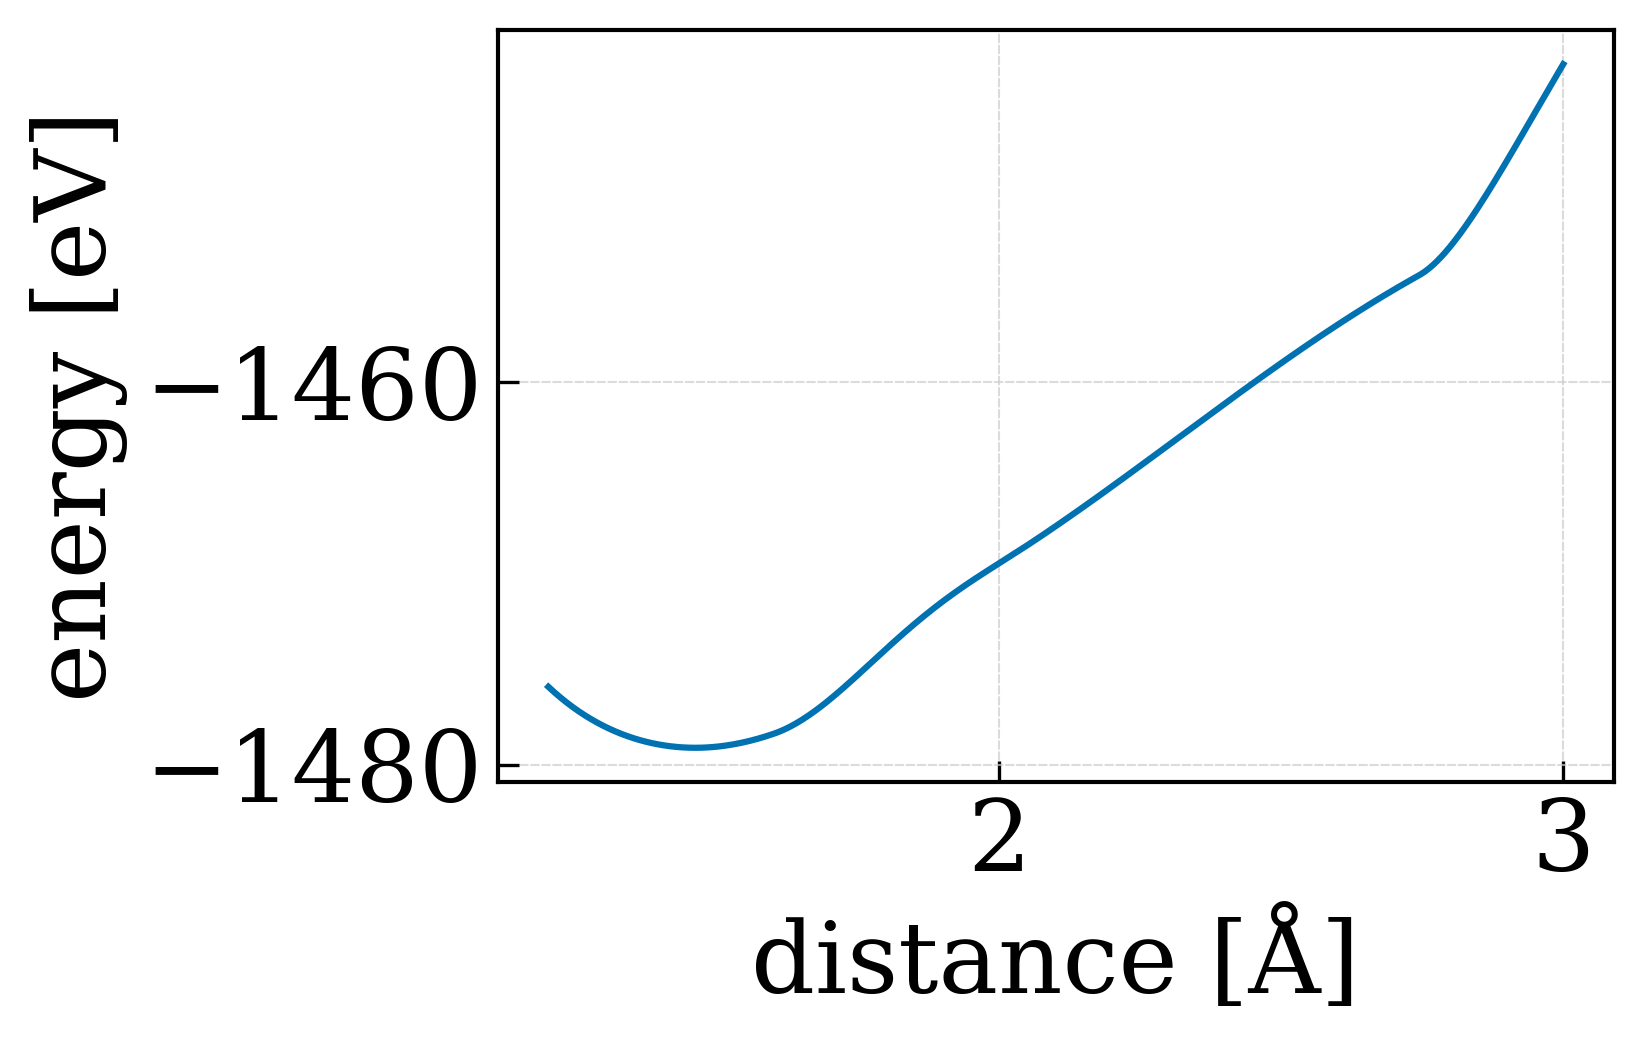

In [16]:
plt.plot(DS, Denergies)
plt.xlabel("distance [Å]")
plt.ylabel("energy [eV]")
plt.savefig("pe_d.svg")
plt.show()

## strained system

In [17]:
strain = np.array([[0.21, 0, 0], [0, 0, 0], [0, 0, 0]])
deformation = np.identity(3) + strain

In [18]:
strained_atoms = atoms.copy()
strained_atoms.positions = base_positions

cell = strained_atoms.cell.array.copy()
print(cell)

cell[0] *= deformation[0][0]   # stretch first lattice vector
print(cell)

strained_atoms.set_cell(cell, scale_atoms=True)
print(strained_atoms.cell)

strained_atoms.calc=calc
strained_positions = strained_atoms.positions.copy()

[[ 25.2967847    0.           0.        ]
 [-12.64839235  21.90765819   0.        ]
 [  0.           0.         100.        ]]
[[ 30.60910949   0.           0.        ]
 [-12.64839235  21.90765819   0.        ]
 [  0.           0.         100.        ]]
Cell([[30.609109491412923, 0.0, 0.0], [-12.648392351823523, 21.907658187423866, 0.0], [0.0, 0.0, 100.0]])


In [19]:
np.linalg.norm(strained_atoms.get_positions()[1] - strained_atoms.get_positions()[0])
distances = strained_atoms.get_all_distances()

(0.0, 2.0)

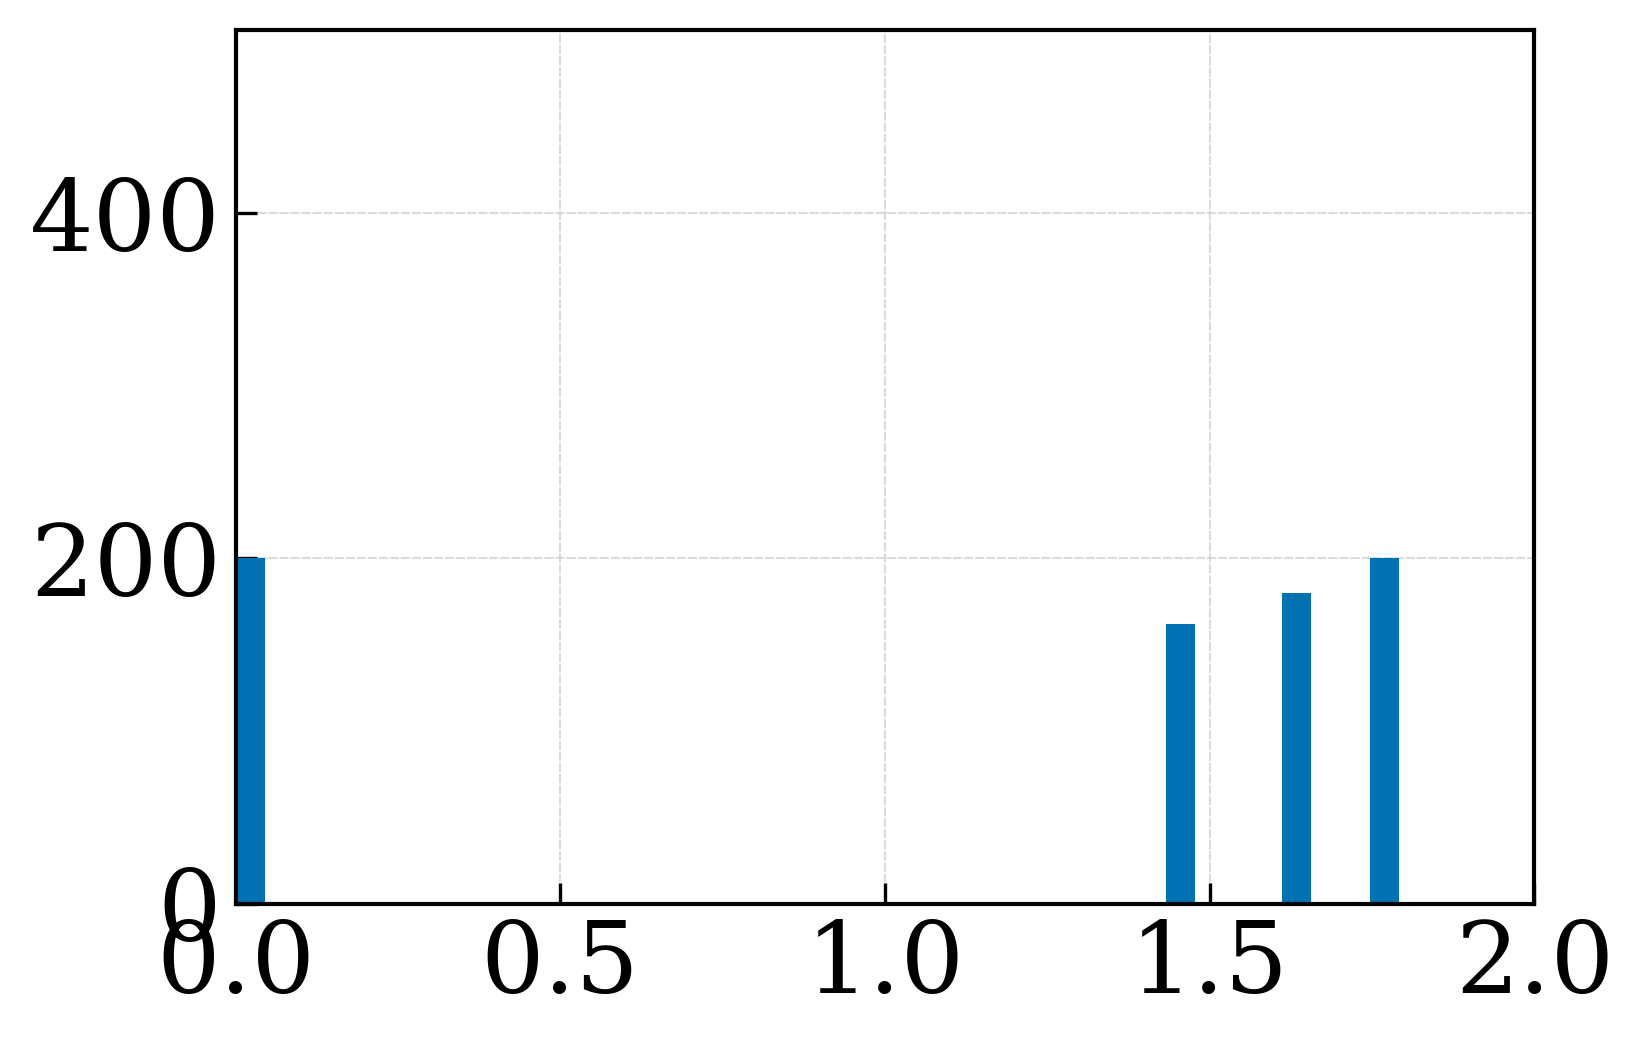

In [20]:
plt.hist(distances.flatten(), bins=1000);
plt.xlim((0, 2))

In [21]:
view(strained_atoms, viewer="x3d")

In [22]:
print(strained_atoms.get_positions())

[[ 5.75552231e-16  4.84741486e-15  2.43981220e-18]
 [ 1.61899422e+00  7.30255273e-01  2.50452536e-18]
 [-1.26483924e+00  2.19076582e+00  2.43981220e-18]
 [ 3.54154986e-01  2.92102109e+00  2.50452536e-18]
 [-2.52967847e+00  4.38153164e+00  2.43981220e-18]
 [-9.10684249e-01  5.11178691e+00  2.50452536e-18]
 [-3.79451771e+00  6.57229746e+00  2.43981220e-18]
 [-2.17552348e+00  7.30255273e+00  2.50452536e-18]
 [-5.05935694e+00  8.76306327e+00  2.43981220e-18]
 [-3.44036272e+00  9.49331855e+00  2.50452536e-18]
 [-6.32419618e+00  1.09538291e+01  2.43981220e-18]
 [-4.70520195e+00  1.16840844e+01  2.50452536e-18]
 [-7.58903541e+00  1.31445949e+01  2.43981220e-18]
 [-5.97004119e+00  1.38748502e+01  2.50452536e-18]
 [-8.85387465e+00  1.53353607e+01  2.43981220e-18]
 [-7.23488043e+00  1.60656160e+01  2.50452536e-18]
 [-1.01187139e+01  1.75261265e+01  2.43981220e-18]
 [-8.49971966e+00  1.82563818e+01  2.50452536e-18]
 [-1.13835531e+01  1.97168924e+01  2.43981220e-18]
 [-9.76455890e+00  2.04471476e+

In [23]:
ND  = 100
DS = np.linspace(1.4, 3, num=ND)
Sforces0=[]
Sforces1=[]
Senergies=[]

strainedv0 = strained_positions[1] - strained_positions[0]
strainedv0 = strainedv0 / np.linalg.norm(strainedv0)
strainedCM = (strained_positions[1] + strained_positions[0]) / 2.0

for d in tqdm(DS):
    pos = strained_positions.copy()

    # keep center fixed
    pos[0] = strainedCM - 0.5*d*strainedv0
    pos[1] = strainedCM + 0.5*d*strainedv0

    strained_atoms.set_positions(pos)

    # evaluation
    E = strained_atoms.get_potential_energy()
    F = strained_atoms.get_forces()

    Senergies.append(E)
    Sforces0.append(F[0].copy())
    Sforces1.append(F[1].copy())


100%|██████████| 100/100 [00:08<00:00, 11.86it/s]


In [24]:
Sforces0=np.array(Sforces0).reshape((ND, 3))
Sforces1=np.array(Sforces1).reshape((ND, 3))
SEnergies = np.array(E)

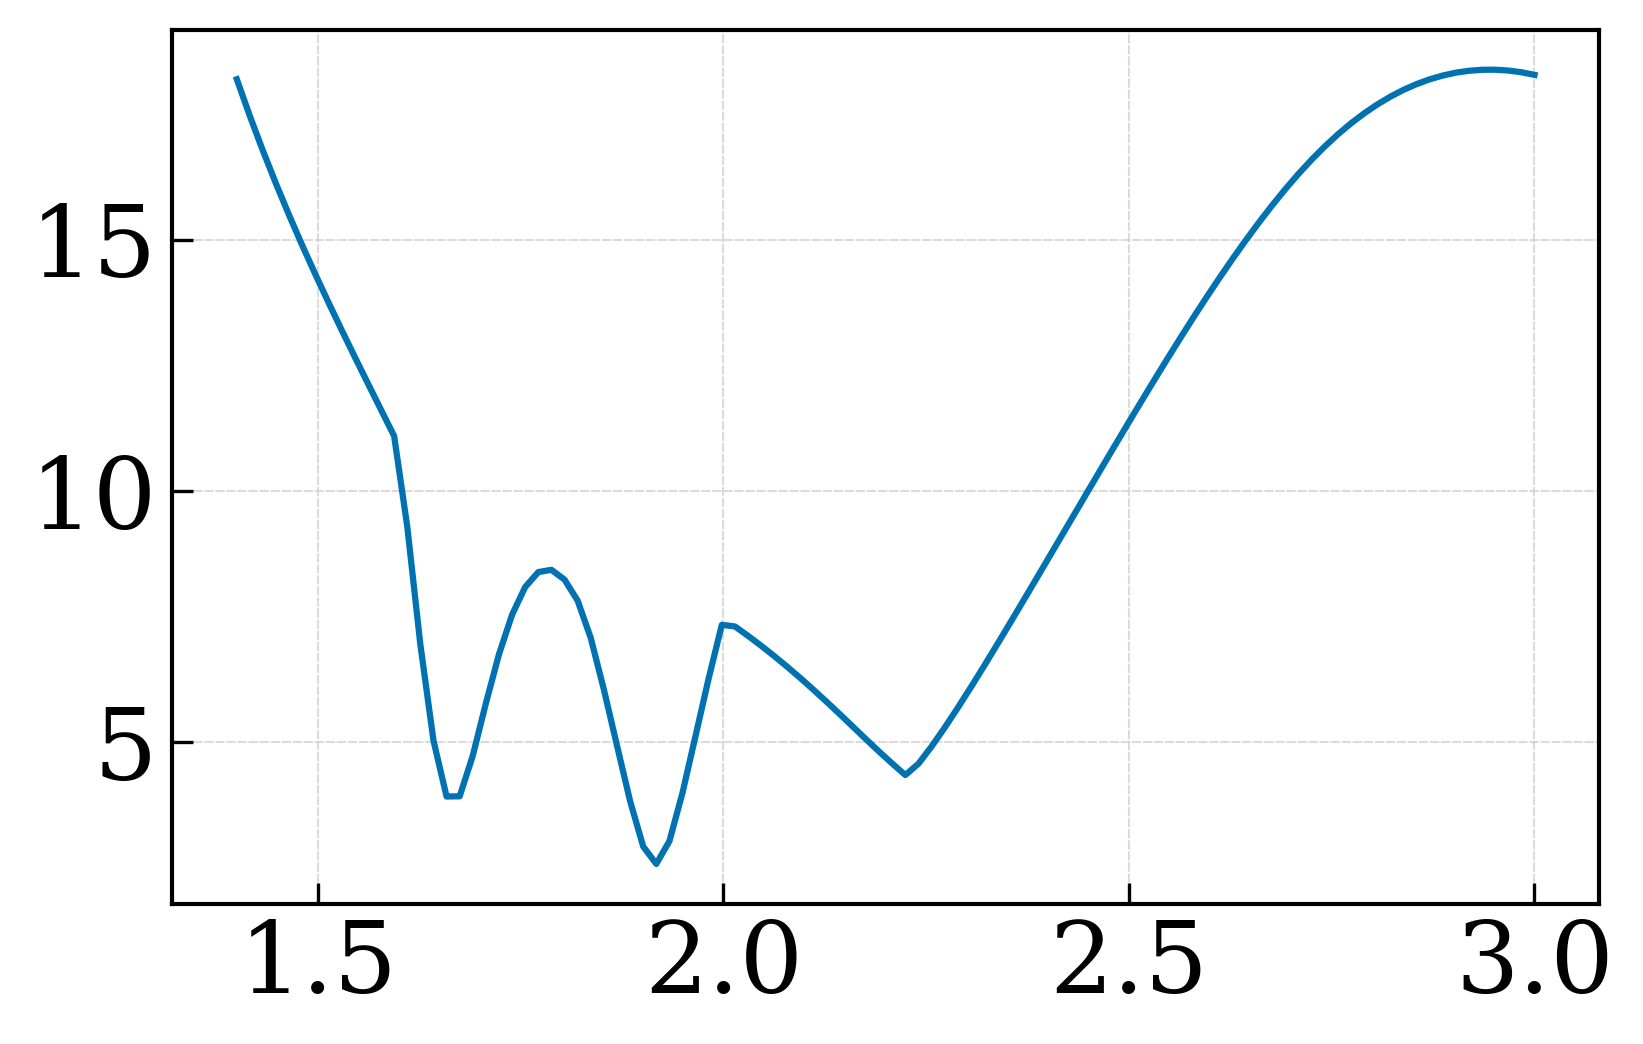

In [25]:
Sforces0norm = np.linalg.norm(Sforces0, axis=-1)
plt.plot(DS, Sforces0norm)

In [26]:
min_idx = np.argmin(Sforces0norm)

In [27]:
min_dist = DS[min_idx]
print(min_dist)

1.917171717171717
